In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

#add ../ to the path
import sys
sys.path.insert(0, '../')

import evaluate_utils
import viz_utils
import importlib
import data_utils
importlib.reload(evaluate_utils)
importlib.reload(viz_utils)
importlib.reload(data_utils)
from evaluate_utils import *
from viz_utils import viz
from data_utils import *

In [13]:
five_batch_results = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/5_batches_64_evals', num_evals = 64, num_batches=5)
full_test_set_results = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/full_set_4_evals', num_evals = 4)
RRUFF_non_aug_model = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)
RRUFF_aug_model = viz.result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)    

100%|██████████| 64/64 [00:05<00:00, 11.94it/s]


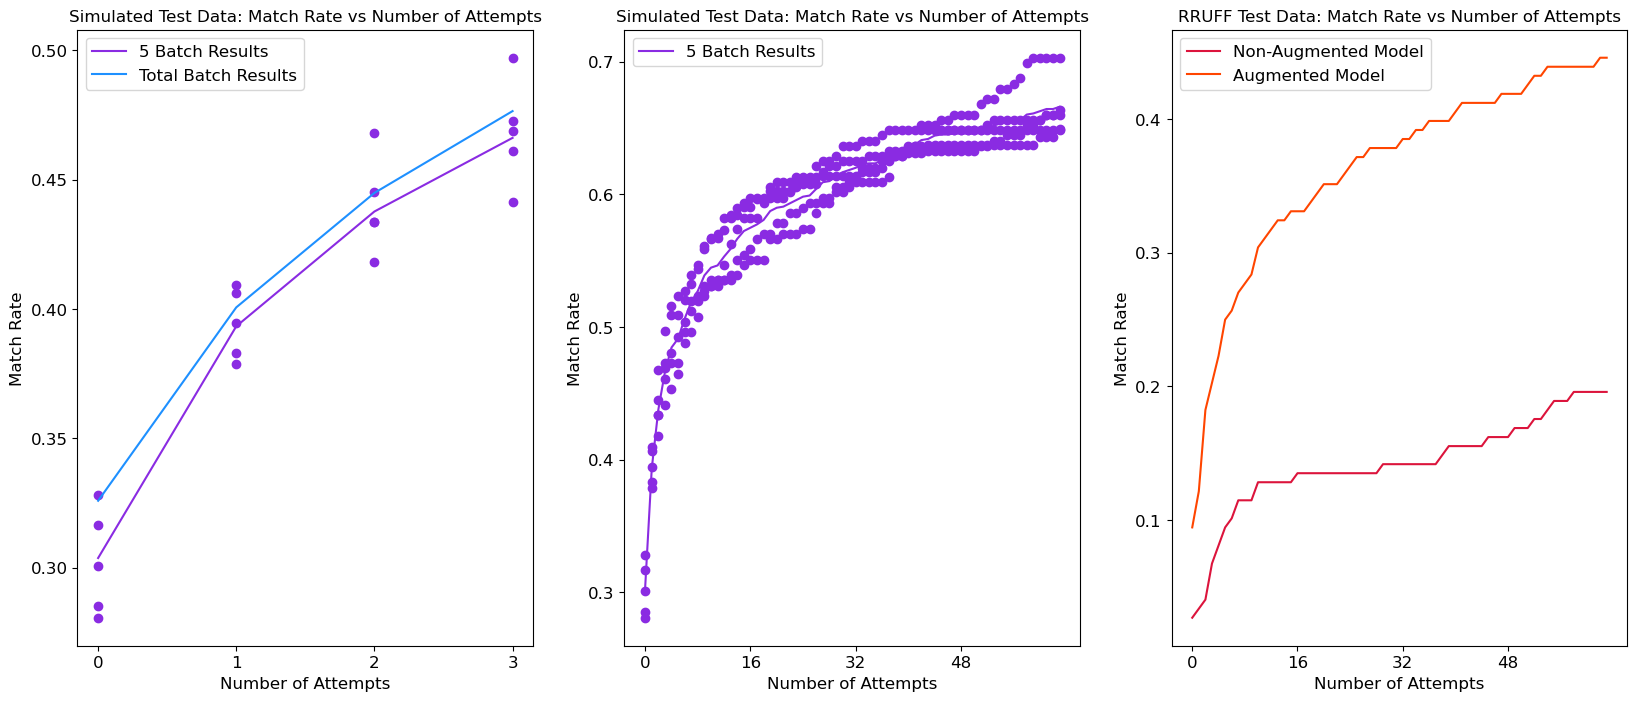

In [59]:
first_fig, dataframes = first_evaluation_figure(full_test_set_results, five_batch_results, RRUFF_non_aug_model, RRUFF_aug_model)

In [6]:
#saving data
result_directory = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data"
data_names = ['full_test_set_results', 'five_batch_results', 'RRUFF_results']
for dataframe, data_name in zip(dataframes, data_names):
    dataframe.to_csv(os.path.join(result_directory, f'{data_name}.csv'))

In [60]:
import torch
import pandas as pd

snapped_crystal_list = torch.load("/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/Snapped_Compounds/snapped_crystal_list.pt")
gt_crystal_list = torch.load("/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/Snapped_Compounds/gt_crystal_list.pt")

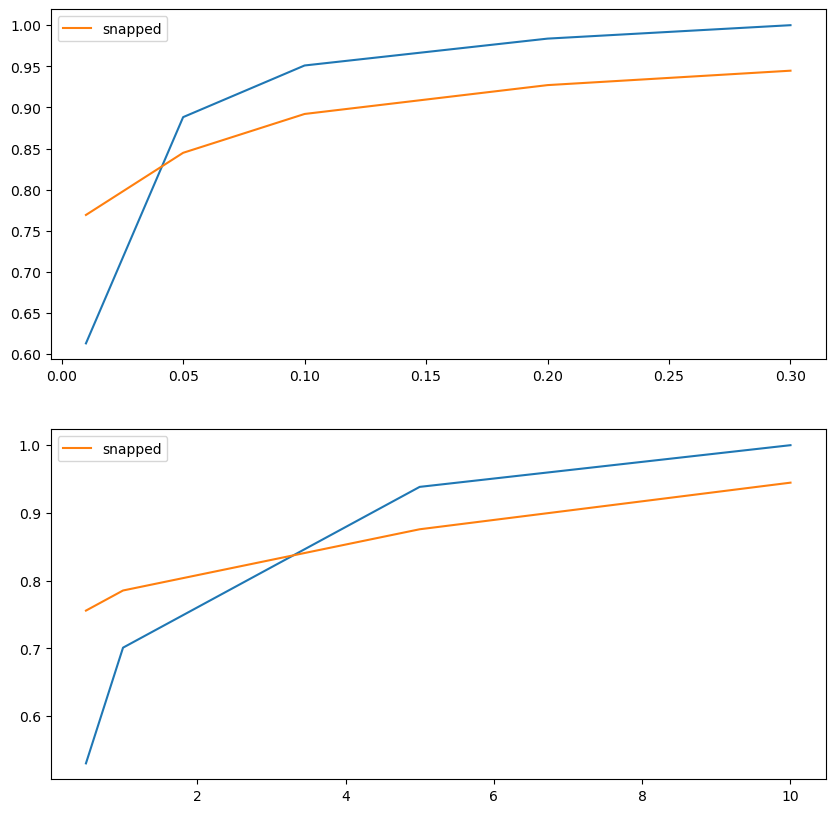

In [42]:
# fig, axs = plt.subplots(2, 1, figsize = (10, 10))
# ltol_values = [0.01, 0.05, 0.1, 0.2, 0.3]
# angle_tol_values = [0.5, 1.0, 5.0, 10.0]

# axs[0].plot(ltol_values, five_batch_results.ltols_per_tol[:, 63] * 1 / (np.max(five_batch_results.ltols_per_tol[:, 63])))
# axs[0].plot(ltol_values, five_batch_results.snapped_ltols_per_tol[:, 0], label = 'snapped')
# axs[0].legend()

# axs[1].plot(angle_tol_values, five_batch_results.atols_per_tol[:, 63] * 1 / (np.max(five_batch_results.atols_per_tol[:, 63])))
# axs[1].plot(angle_tol_values, five_batch_results.snapped_atols_per_tol[:, 0], label = 'snapped')
# axs[1].legend()